# rxnfp + CatEmb dimension benchmark

In [18]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
json_path = repo_root / "benchmark_results" / "rxnfp_catemb_qspr" / "aryl_scope_rxnfp_catemb_qspr.json"

with json_path.open() as f:
    data = json.load(f)

df = pd.DataFrame([
    {
        "strategy": item["strategy_name"],
        "dim": item["catemb_dim"],
        "r2_mean": item["metrics_summary"]["r2_mean"],
    }
    for item in data["random_results"] if item['model_type'] == 'ExtraTrees' and item['strategy_name'] == 'aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst'
]).sort_values(["strategy", "dim"])

dims = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
df

,strategy,dim,r2_mean
0,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,8,0.741047
1,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,16,0.762852
2,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,32,0.768725
3,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,64,0.775933
4,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,128,0.788449
5,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,256,0.786576
6,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,512,0.791852
7,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,1024,0.796244
8,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,2048,0.803764
9,aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst,4096,0.804798


In [19]:
def plot_strategy(df, ax, strategy, label, marker="o", linestyle="-", line_color="0.45"):
    sub = df[df["strategy"].eq(strategy)].set_index("dim").loc[dims].reset_index()
    best_i = sub["r2_mean"].idxmax()
    colors = ["tab:blue" if i == best_i else "tab:red" for i in sub.index]

    ax.plot(sub["dim"], sub["r2_mean"], linestyle=linestyle, color=line_color, lw=1.8, label=label)
    ax.scatter(sub["dim"], sub["r2_mean"], c=colors, marker=marker, s=70, edgecolor="black", zorder=3)

    ax.set_xscale("log", base=2)
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45)
    ax.set_xlabel("CatEmb dimension")
    ax.set_ylabel(r"Mean of $R^2$")
    ax.grid(alpha=0.25)
    ax.margins(x=0.03, y=0.10)

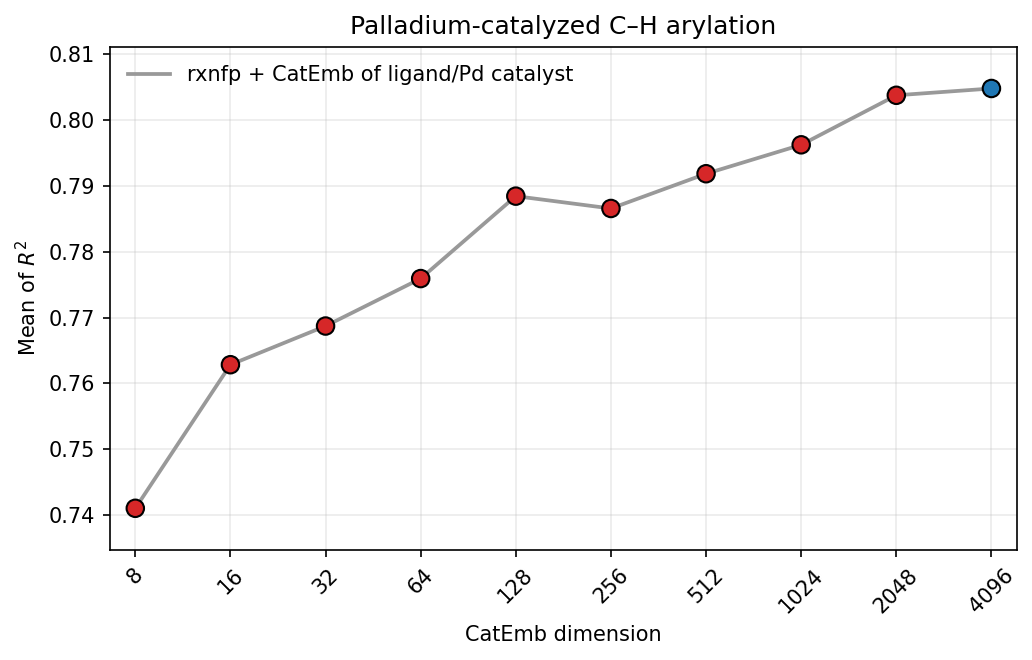

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

plot_strategy(
    df,
    ax,
    "aryl_scope_rxnfp_plus_catemb_ligand_pd_catalyst",
    "rxnfp + CatEmb of ligand/Pd catalyst",
    marker="o",
    linestyle="-",
    line_color="0.60",
)

ax.set_title("Palladium-catalyzed C–H arylation")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

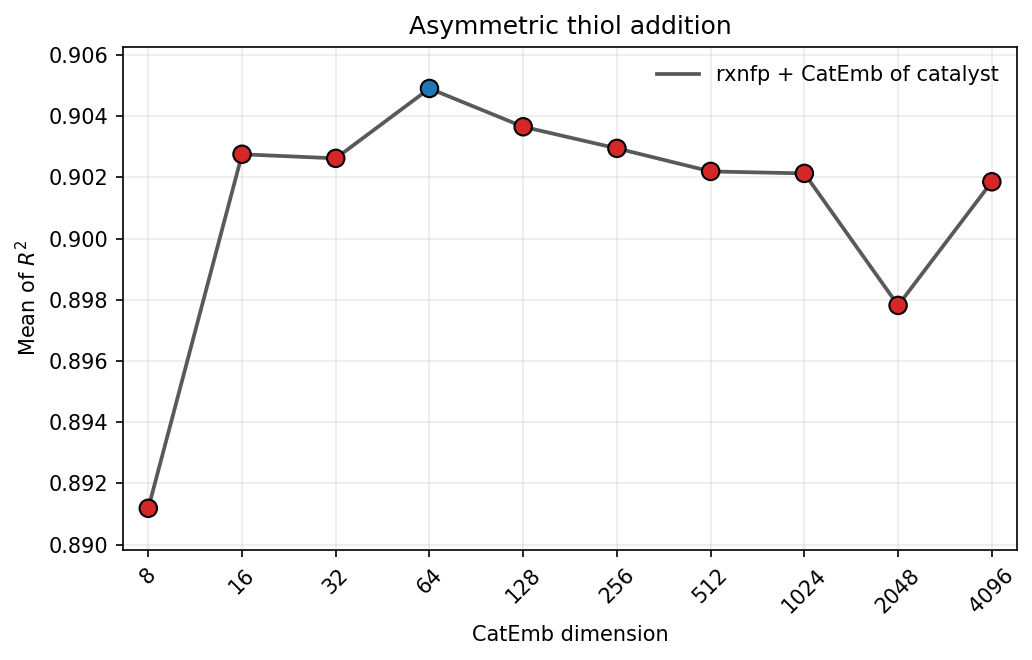

In [22]:

repo_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
json_path = repo_root / "benchmark_results" / "rxnfp_catemb_qspr" / "thiol_addition_rxnfp_catemb_qspr.json"

with json_path.open() as f:
    data = json.load(f)

df = pd.DataFrame([
    {
        "strategy": item["strategy_name"],
        "dim": item["catemb_dim"],
        "r2_mean": item["metrics_summary"]["r2_mean"],
    }
    for item in data["random_results"] if item['model_type'] == 'ExtraTrees'
]).sort_values(["strategy", "dim"])

dims = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]


fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

plot_strategy(
    df,
    ax,
    "thiol_addition_rxnfp_plus_catemb_catalyst",
    "rxnfp + CatEmb of catalyst",
    marker="o",
    linestyle="-",
    line_color="0.35",
)

ax.set_title("Asymmetric thiol addition")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()